## Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

warnings.filterwarnings("ignore", message=".*valid feature names.*")

print("Bibliotheques importees.")

Bibliotheques importees.


## Paramètres

In [2]:
OUTPUT_DIR = "../../outputs/automobile"
TARGET_COL = "price"

EPSILON        = 1e-5   # seuil de convergence de la dichotomie
MAX_ITER       = 100    # nombre max d'iterations de la dichotomie (par saut)
MAX_HOPS       = 4       # nombre max de sauts (motifs chaines)
SEUIL_VALIDITE = 0.01   # tolerance (1%) pour la metrique de validite

## Chargement du modèle, des motifs et des données

In [3]:
print("[Contrefactuels] Chargement du modele SVM, des motifs et des donnees...")

model = joblib.load(f"{OUTPUT_DIR}/svm_model.pkl")
motifs_ascendants  = pd.read_csv(f"{OUTPUT_DIR}/motifs_ascendants.csv", sep=";")
motifs_descendants = pd.read_csv(f"{OUTPUT_DIR}/motifs_descendants.csv", sep=";")

X_train = pd.read_csv(f"{OUTPUT_DIR}/X_train.csv", sep=";")
X_test  = pd.read_csv(f"{OUTPUT_DIR}/X_test.csv", sep=";")
y_test  = pd.read_csv(f"{OUTPUT_DIR}/y_test.csv", sep=";")[TARGET_COL]

print(f"[Contrefactuels] {len(X_test)} instances de test disponibles.")

[Contrefactuels] Chargement du modele SVM, des motifs et des donnees...


[Contrefactuels] 32 instances de test disponibles.


## Fonctions utilitaires internes (helpers)

In [4]:
# Ces fonctions sont des briques internes appelees UNIQUEMENT par la fonction
# principale generer_contrefactuels() (cellule suivante). L'utilisateur du
# notebook n'a besoin d'appeler que generer_contrefactuels().

def _attrs_of(motif_str):
    """Renvoie l'ensemble des attributs impliques dans un motif."""
    return set(item.rsplit("=", 1)[0] for item in motif_str.split(", "))


def _utilisable(row, f_courant, sens):
    """Une sequence est utilisable comme saut si elle couvre f_courant, dans le bon sens."""
    if sens == "+":
        return row["cible_depart"] <= f_courant < row["cible_arrivee"]
    else:
        return row["cible_depart"] >= f_courant > row["cible_arrivee"]


def _progression(row, sens):
    """Score de progression : plus la sequence avance loin vers la cible, mieux c'est."""
    return row["cible_arrivee"] if sens == "+" else -row["cible_arrivee"]


def _cible_atteinte(f_courant, y_cible, epsilon):
    """Critere de convergence (identique a celui de la dichotomie)."""
    return abs(f_courant - y_cible) < epsilon * abs(y_cible)


def _predict_one(model, x_vec):
    """Prediction rapide sur un seul vecteur numpy (evite de reconstruire un
    DataFrame a chaque appel, ce qui accelere fortement le chainage)."""
    return model.predict(x_vec.reshape(1, -1))[0]


def _motif_est_valide(x_vec, motif_str, model, f_courant, sens, extremes):
    """Verifie qu'en poussant les attributs du motif a leurs extremes (vus
    dans le train), la prediction varie bien dans le sens souhaite."""
    x_test = x_vec.copy()
    for item in motif_str.split(", "):
        col, direction = item.rsplit("=", 1)
        if col in extremes:
            idx, vmin, vmax = extremes[col]
            x_test[idx] = vmax if direction == "+" else vmin
    pred_test = _predict_one(model, x_test)
    if sens == "+" and pred_test > f_courant:
        return True, pred_test
    if sens == "-" and pred_test < f_courant:
        return True, pred_test
    return False, pred_test


def _generer_saut(x_vec, motif_str, model, sous_cible, sens, epsilon, max_iter, extremes):
    """Algorithme 1 du memoire : recherche dichotomique d'un seul saut."""
    x_prime   = x_vec.copy()
    x_courant = x_vec.copy()
    for item in motif_str.split(", "):
        col, direction = item.rsplit("=", 1)
        if col in extremes:
            idx, vmin, vmax = extremes[col]
            x_prime[idx] = vmax if direction == "+" else vmin

    historique = []
    pred_temp = None
    for iteration in range(max_iter):
        x_temp = (x_courant + x_prime) / 2
        pred_temp = _predict_one(model, x_temp)
        historique.append({"iteration": iteration + 1, "f_x_temp": round(float(pred_temp), 2)})

        if sens == "+":
            if pred_temp >= sous_cible: x_prime = x_temp
            else: x_courant = x_temp
        else:
            if pred_temp <= sous_cible: x_prime = x_temp
            else: x_courant = x_temp

        if abs(pred_temp - sous_cible) < epsilon * abs(sous_cible):
            break

    return x_prime, pred_temp, historique


def _chercher_chemin(x_courant, f_courant, y_cible, sens, attributs_utilises, chemin,
                      profondeur, motifs_df, model, extremes, max_hops, epsilon, max_iter):
    """Algorithme 2 du memoire : chainage recursif avec retour sur trace (backtracking)."""
    if _cible_atteinte(f_courant, y_cible, epsilon):
        return (x_courant, f_courant, chemin)
    if profondeur >= max_hops:
        return None

    candidats = []
    for _, row in motifs_df.iterrows():
        if not _utilisable(row, f_courant, sens):
            continue
        if not _attrs_of(row["motif"]).isdisjoint(attributs_utilises):
            continue
        valide, _ = _motif_est_valide(x_courant, row["motif"], model, f_courant, sens, extremes)
        if not valide:
            continue
        candidats.append(row)

    candidats.sort(key=lambda r: (_progression(r, sens), r["support"]), reverse=True)

    for row in candidats:
        sous_cible = min(row["cible_arrivee"], y_cible) if sens == "+" else max(row["cible_arrivee"], y_cible)
        x_next, pred_next, historique = _generer_saut(x_courant, row["motif"], model, sous_cible, sens,
                                                        epsilon, max_iter, extremes)
        saut = {"motif": row["motif"], "support": row["support"], "sous_cible": round(sous_cible, 2),
                "f_apres": round(float(pred_next), 2), "historique": historique}

        resultat = _chercher_chemin(x_next, pred_next, y_cible, sens,
                                     attributs_utilises | _attrs_of(row["motif"]),
                                     chemin + [saut], profondeur + 1, motifs_df, model,
                                     extremes, max_hops, epsilon, max_iter)
        if resultat is not None:
            return resultat
    return None

print("Fonctions utilitaires de la Phase 3 definies.")

Fonctions utilitaires de la Phase 3 definies.


## LA fonction unique de la Phase 3

In [5]:
def generer_contrefactuels(x, model, y_cible, motifs_ascendants, motifs_descendants,
                            data_train, epsilon=1e-5, max_iter=100, max_hops=4, verbose=True):
    """
    Fonction UNIQUE de la Phase 3 (voir memoire, section 3.5).

    Entrees :
        x                  : DataFrame d'une seule ligne (l'instance a expliquer)
        model              : modele de regression entraine (methode .predict)
        y_cible            : valeur cible souhaitee pour la prediction
        motifs_ascendants  : DataFrame des motifs extraits avec ascending=True (Phase 1)
        motifs_descendants : DataFrame des motifs extraits avec ascending=False (Phase 1)
        data_train         : DataFrame des donnees d'entrainement (valeurs extremes)
        epsilon, max_iter, max_hops : hyperparametres (cf. memoire, Tableau 4.4)
        verbose            : si True, affiche des logs de progression

    Sortie :
        liste de dictionnaires, un par contrefactuel trouve, avec les cles :
        fx_cible, motif, nb_sauts, chemin, support, pred_cf, contrefactuel, historique
        (structure identique a celle du memoire)
    """
    cols = x.columns.tolist()
    # Bornes min/max de chaque attribut dans le train, precalculees une fois
    extremes = {c: (i, data_train[c].min(), data_train[c].max()) for i, c in enumerate(cols)}
    x_vec = x.values.flatten().astype(float)
    fx = _predict_one(model, x_vec)

    # Deduction automatique du sens et choix du bon jeu de motifs
    if y_cible > fx:
        sens, motifs_df = "+", motifs_ascendants
    elif y_cible < fx:
        sens, motifs_df = "-", motifs_descendants
    else:
        if verbose:
            print("[Phase 3] y_cible == f(x) : aucune modification necessaire.")
        return []

    if verbose:
        print(f"[Phase 3] f(x) = {fx:.2f} | cible y' = {y_cible:.2f} | sens = {sens}")
        print("[Phase 3] Recherche des premiers sauts valides...")

    # --- Etape 1 : recherche des premiers sauts valides depuis x ---
    candidats0 = []
    for _, row in motifs_df.iterrows():
        if not _utilisable(row, fx, sens):
            continue
        valide, _ = _motif_est_valide(x_vec, row["motif"], model, fx, sens, extremes)
        if not valide:
            continue
        candidats0.append(row)

    if verbose:
        print(f"[Phase 3]   -> {len(candidats0)} premier(s) saut(s) valide(s) trouve(s)")

    # --- Etapes 2/3 : un contrefactuel PAR premier saut valide (diversite) ---
    contrefactuels = []
    for row in candidats0:
        sous_cible = min(row["cible_arrivee"], y_cible) if sens == "+" else max(row["cible_arrivee"], y_cible)
        x1, pred1, hist1 = _generer_saut(x_vec, row["motif"], model, sous_cible, sens, epsilon, max_iter, extremes)
        saut1 = {"motif": row["motif"], "support": row["support"], "sous_cible": round(sous_cible, 2),
                 "f_apres": round(float(pred1), 2), "historique": hist1}

        if _cible_atteinte(pred1, y_cible, epsilon):
            chemin_final, x_final_vec, pred_final = [saut1], x1, pred1
        else:
            resultat = _chercher_chemin(x1, pred1, y_cible, sens, _attrs_of(row["motif"]),
                                         [saut1], 1, motifs_df, model, extremes,
                                         max_hops, epsilon, max_iter)
            if resultat is None:
                continue
            x_final_vec, pred_final, chemin_final = resultat

        motif_desc  = " -> ".join(s["motif"] for s in chemin_final)
        support_min = min(s["support"] for s in chemin_final)
        historique_concat, offset = [], 0
        for s in chemin_final:
            for h in s["historique"]:
                historique_concat.append({"iteration": h["iteration"] + offset, "f_x_temp": h["f_x_temp"]})
            offset += len(s["historique"])

        contrefactuels.append({
            "fx_cible"     : round(float(y_cible), 2),
            "motif"        : motif_desc,
            "nb_sauts"     : len(chemin_final),
            "chemin"       : chemin_final,
            "support"      : round(float(support_min), 3),
            "pred_cf"      : round(float(pred_final), 2),
            "contrefactuel": pd.Series(x_final_vec, index=cols),
            "historique"   : historique_concat,
        })

    if verbose:
        nb_directs = sum(1 for c in contrefactuels if c["nb_sauts"] == 1)
        print(f"[Phase 3] Termine : {len(contrefactuels)} contrefactuel(s) "
              f"({nb_directs} direct(s), {len(contrefactuels) - nb_directs} chaine(s))")

    return contrefactuels

print("Fonction generer_contrefactuels() definie.")

Fonction generer_contrefactuels() definie.


## Génération pour une instance choisie

In [6]:
# Choisis ici l'indice (dans X_test) de l'instance a expliquer, et la cible souhaitee
INDEX_INSTANCE = 0
Y_CIBLE = None   # None => on met un delta d'exemple ci-dessous ; sinon fixe une valeur precise

x_instance = X_test.iloc[[INDEX_INSTANCE]]
fx_instance = _predict_one(model, x_instance.values.flatten().astype(float))

if Y_CIBLE is None:
    Y_CIBLE = fx_instance + 1000   # exemple : on vise +2000$ par rapport a f(x)

print(f"[Instance {INDEX_INSTANCE}] f(x) = {fx_instance:.2f} | cible y' = {Y_CIBLE:.2f}")

t0 = time.time()
contrefactuels_instance = generer_contrefactuels(
    x_instance, model, Y_CIBLE, motifs_ascendants, motifs_descendants,
    X_train, epsilon=EPSILON, max_iter=MAX_ITER, max_hops=MAX_HOPS
)
print(f"[Instance {INDEX_INSTANCE}] Temps ecoule : {time.time() - t0:.1f}s")

[Instance 0] f(x) = 10922.65 | cible y' = 11922.65
[Phase 3] f(x) = 10922.65 | cible y' = 11922.65 | sens = +
[Phase 3] Recherche des premiers sauts valides...
[Phase 3]   -> 3 premier(s) saut(s) valide(s) trouve(s)
[Phase 3] Termine : 2 contrefactuel(s) (0 direct(s), 2 chaine(s))
[Instance 0] Temps ecoule : 13.9s


## Sauvegarde des contrefactuels de l'instance

In [7]:
if len(contrefactuels_instance) == 0:
    print("Aucun contrefactuel trouve pour cette instance.")
else:
    x_orig = x_instance.iloc[0]
    rows = [{"motif": "-", "nb_sauts": "-", "support": "-", "pred_cible": "-",
             **{c: round(x_orig[c], 4) for c in x_instance.columns}, TARGET_COL: round(fx_instance, 2)}]

    for cf in contrefactuels_instance:
        x_cf = cf["contrefactuel"]
        ligne = {"motif": cf["motif"], "nb_sauts": cf["nb_sauts"], "support": cf["support"],
                 "pred_cible": cf["fx_cible"]}
        for col in x_instance.columns:
            if abs(x_orig[col] - x_cf[col]) > 1e-6:
                fleche = "up" if x_cf[col] > x_orig[col] else "down"
                ligne[col] = f"{round(x_cf[col], 4)} ({fleche})"
            else:
                ligne[col] = "-"
        ligne[TARGET_COL] = f"{cf['pred_cf']} ({'up' if cf['pred_cf'] > fx_instance else 'down'})"
        rows.append(ligne)

    df_cf = pd.DataFrame(rows)
    df_cf.to_csv(f"{OUTPUT_DIR}/contrefactuels_instance_{INDEX_INSTANCE}.csv", index=False, sep=";")
    print(df_cf.to_string(index=False))

                                                           motif nb_sauts support pred_cible normalized_losses   wheel_base        length width height    curb_weight engine_size  bore stroke compression_ratio horsepower peak_rpm city_mpg highway_mpg         price
                                                               -        -       -          -             102.0         97.0         172.0  65.4   54.3         2510.0       108.0  3.62   2.64               7.7      111.0   4800.0     24.0        29.0      10922.65
                       length=+ -> wheel_base=+ -> curb_weight=+        3   0.433   11922.65                 - 97.0091 (up) 182.2797 (up)     -      - 2879.2461 (up)           -     -      -                 -          -        -        -           -  11922.6 (up)
compression_ratio=- -> length=+ -> wheel_base=+ -> curb_weight=+        4   0.433   11922.65                 - 97.0136 (up) 181.8613 (up)     -      - 2878.1064 (up)           -     -      -        7.5 (down)

## Graphe de convergence

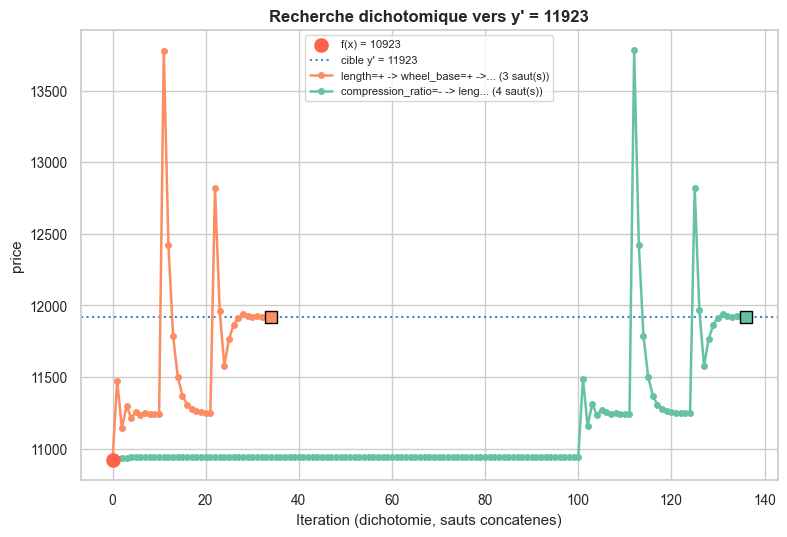

In [8]:
tous_les_cfs = [cf for cf in contrefactuels_instance if len(cf["historique"]) > 0]

if len(tous_les_cfs) == 0:
    print("Aucun contrefactuel avec historique a tracer.")
else:
    sns.set_theme(style="whitegrid", font_scale=0.9)
    fig, ax = plt.subplots(figsize=(8, 5.5))

    motifs_uniques = list({cf["motif"] for cf in tous_les_cfs})
    palette = {m: c for m, c in zip(motifs_uniques, sns.color_palette("Set2", len(motifs_uniques)))}

    ax.scatter([0], [fx_instance], color="tomato", zorder=5, s=90, label=f"f(x) = {fx_instance:.0f}")
    ax.axhline(y=Y_CIBLE, color="steelblue", linewidth=1.5, linestyle=":", label=f"cible y' = {Y_CIBLE:.0f}")

    for cf in tous_les_cfs:
        iterations = [0] + [h["iteration"] for h in cf["historique"]]
        f_vals     = [fx_instance] + [h["f_x_temp"] for h in cf["historique"]]
        couleur    = palette[cf["motif"]]
        label = (cf["motif"][:27] + "..." if len(cf["motif"]) > 30 else cf["motif"]) + f" ({cf['nb_sauts']} saut(s))"
        ax.plot(iterations, f_vals, color=couleur, linewidth=1.8, marker="o", markersize=4, label=label)
        ax.scatter(iterations[-1], cf["pred_cf"], color=couleur, zorder=6, s=80,
                   edgecolors="black", linewidths=1, marker="s")

    ax.set_title(f"Recherche dichotomique vers y' = {Y_CIBLE:.0f}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Iteration (dichotomie, sauts concatenes)")
    ax.set_ylabel(TARGET_COL)
    ax.legend(fontsize=8, loc="best")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/graphe_instance_{INDEX_INSTANCE}.png", dpi=150, bbox_inches="tight")
    plt.show()

## Fonction de calcul des métriques

In [9]:
def calculer_metriques(x_orig_df, contrefactuels, y_cible, seuil_validite=0.03):
    """Calcule validite, proximite, sparsite, diversite pour un groupe de
    contrefactuels visant la meme cible, pour une seule instance de depart."""
    n = len(contrefactuels)
    if n == 0:
        return None

    x0 = x_orig_df.iloc[0]
    mad = x_orig_df.apply(lambda col: np.median(np.abs(col - col.median())), axis=0)
    mad = mad.replace(0, 1)

    nb_valides = sum(1 for cf in contrefactuels if abs(cf["pred_cf"] - y_cible) < seuil_validite * abs(y_cible))
    validite = nb_valides / n

    proximites = [np.mean([abs(x0[c] - cf["contrefactuel"][c]) / mad[c] for c in x0.index]) for cf in contrefactuels]
    proximite = np.mean(proximites)

    nb_cols = len(x0)
    sparsites = [1 - sum(1 for c in x0.index if abs(x0[c] - cf["contrefactuel"][c]) > 1e-6) / nb_cols
                 for cf in contrefactuels]
    sparsite = np.mean(sparsites)

    if n < 2:
        diversite = 0.0
    else:
        paires = []
        for i in range(n):
            for j in range(i + 1, n):
                xi, xj = contrefactuels[i]["contrefactuel"], contrefactuels[j]["contrefactuel"]
                paires.append(np.mean([abs(xi[c] - xj[c]) / mad[c] for c in x0.index]))
        diversite = np.mean(paires)

    return {"nb": n, "validite": round(float(validite), 4), "proximite": round(float(proximite), 4),
            "sparsite": round(float(sparsite), 4), "diversite": round(float(diversite), 4)}


metriques_instance = calculer_metriques(x_instance, contrefactuels_instance, Y_CIBLE, SEUIL_VALIDITE)
print(f"[Instance {INDEX_INSTANCE}] Metriques : {metriques_instance}")

[Instance 0] Metriques : {'nb': 2, 'validite': 1.0, 'proximite': 27.0613, 'sparsite': 0.75, 'diversite': 0.1259}


## Évaluation sur les 20% de test

In [ ]:
# Delta absolu fixe (deduit de l'instance illustrative ci-dessus), applique
# a TOUTES les instances du test set, comme demande.
DELTA = Y_CIBLE - fx_instance
print(f"[Batch] Delta applique a toutes les instances de test : {DELTA:+.2f}")
print(f"[Batch] Evaluation sur les {len(X_test)} instances du test set...")
print("[Batch] Attention : selon le dataset, ceci peut prendre plusieurs minutes")
print("[Batch] (certaines instances necessitent d'explorer beaucoup de motifs avant d'echouer).")

t0 = time.time()
metriques_toutes = []
nb_sans_cf = 0

for idx in range(len(X_test)):
    x_i  = X_test.iloc[[idx]]
    fx_i = _predict_one(model, x_i.values.flatten().astype(float))
    y_cible_i = fx_i + DELTA

    if y_cible_i == fx_i:
        continue

    cfs_i = generer_contrefactuels(x_i, model, y_cible_i, motifs_ascendants, motifs_descendants,
                                    X_train, epsilon=EPSILON, max_iter=MAX_ITER, max_hops=MAX_HOPS,
                                    verbose=False)
    if len(cfs_i) == 0:
        nb_sans_cf += 1
        continue

    m_i = calculer_metriques(x_i, cfs_i, y_cible_i, SEUIL_VALIDITE)
    metriques_toutes.append(m_i)

    if (idx + 1) % 5 == 0:
        print(f"[Batch]  ... {idx + 1}/{len(X_test)} instances traitees "
              f"({time.time() - t0:.0f}s ecoulees, {nb_sans_cf} sans contrefactuel)")

print(f"\n[Batch] Termine en {time.time() - t0:.1f}s. "
      f"{len(metriques_toutes)} instances avec contrefactuel(s), {nb_sans_cf} sans solution.")

## Moyenne des métriques et sauvegarde

In [ ]:
if len(metriques_toutes) == 0:
    print("Aucune metrique disponible sur le test set.")
else:
    df_m = pd.DataFrame(metriques_toutes)
    moyennes = df_m.mean(numeric_only=True).round(4)

    print("=" * 50)
    print(f"  METRIQUES MOYENNES SUR LE TEST SET (delta = {DELTA:+.2f})")
    print("=" * 50)
    print(moyennes)

    resultat_global = {
        "delta": round(DELTA, 2),
        "n_instances_avec_cf": len(metriques_toutes),
        "n_instances_sans_cf": nb_sans_cf,
        **moyennes.to_dict()
    }
    pd.DataFrame([resultat_global]).to_csv(f"{OUTPUT_DIR}/metriques_test_set.csv", index=False, sep=";")
    print(f"\nSauvegarde dans {OUTPUT_DIR}/metriques_test_set.csv")